# Tugas Klasifikasi
sumber data : https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction?resource=download
 Attribute Information
- Age: age of the patient [years]
- Sex: sex of the patient [M: Male, F: Female]
- ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP: resting blood pressure [mm Hg]
- Cholesterol: serum cholesterol [mm/dl]
- FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- Oldpeak: oldpeak = ST [Numeric value measured in depression]
- ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease: output class [1: heart disease, 0: Normal]

In [1]:
# Import Library
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches
from matplotlib import cm

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score,
    recall_score, average_precision_score, precision_recall_curve
)
from sklearn.inspection import permutation_importance

# Model yang akan dicoba
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (
    RandomForestClassifier,   # Bagging
    ExtraTreesClassifier,     # Extreme Randomised Trees
    AdaBoostClassifier,       # Boosting
    GradientBoostingClassifier,  # Boosting
    BaggingClassifier,        # Generic Bagging
    VotingClassifier,         # Ensemble – Voting
    StackingClassifier,       # Ensemble – Stacking
)
from sklearn.svm           import SVC
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
)

1. Logistic Regression
- Kegunaan:
Logistic Regression digunakan untuk klasifikasi data, terutama klasifikasi biner seperti “ya atau tidak”, “lulus atau tidak lulus”, dan “terkena penyakit atau tidak”. Model ini menghitung probabilitas suatu data masuk ke dalam kelas tertentu.
- Kelebihan: Mudah dipahami dan dijelaskan, Proses training cepat, Cocok untuk dataset kecil hingga menengah, Hasil prediksi mudah diinterpretasikan
- Kekurangan:Kurang baik untuk pola data yang kompleks, Mengasumsikan hubungan linear antar variabel, Akurasi bisa kalah dibanding metode ensemble

2. Decision Tree Classifier
- Kegunaan: Decision Tree digunakan untuk membuat keputusan berdasarkan aturan tertentu dalam bentuk pohon bercabang. Model ini sering digunakan untuk klasifikasi maupun prediksi sederhana.
- Kelebihan: Mudah divisualisasikan, Mudah dipahami oleh pengguna non-teknis, Tidak memerlukan normalisasi data
Dapat menangani data numerik maupun kategori
- Kekurangan: Mudah mengalami overfitting, Performa kurang stabil terhadap perubahan data kecil, Akurasi kadang lebih rendah dibanding ensemble learning

3. Random Forest Classifier
- Kegunaan: Random Forest merupakan metode bagging yang menggabungkan banyak decision tree untuk meningkatkan akurasi dan kestabilan prediksi.
- Kelebihan: Akurasi tinggi
Mengurangi overfitting pada decision tree, Stabil untuk berbagai jenis data, Dapat menangani data besar dengan baik
- Kekurangan: Training lebih lambat dibanding decision tree tunggal, Membutuhkan memori lebih besar, Hasil model lebih sulit dijelaskan

4. Extra Trees Classifier
- Kegunaan: Extra Trees digunakan untuk klasifikasi dengan konsep mirip Random Forest, tetapi menggunakan pemilihan split yang lebih acak.
- Kelebihan: Proses training lebih cepat, Mengurangi risiko overfitting, Akurasi cukup tinggi
- Kekurangan: Interpretasi model sulit, Kadang hasil kurang stabil pada data tertentu

5. AdaBoost Classifier
- Kegunaan: AdaBoost digunakan untuk meningkatkan performa model dengan memperbaiki kesalahan prediksi dari model sebelumnya secara bertahap.
- Kelebihan: Akurasi cukup baik, Cocok untuk dataset kecil hingga menengah, Konsep boosting sederhana dan efektif
- Kekurangan: Sensitif terhadap noise dan outlier, Training bisa lebih lama jika estimator banyak

6. Gradient Boosting Classifier
- Kegunaan: Gradient Boosting digunakan untuk menghasilkan model prediksi yang kuat melalui proses boosting bertahap.
- Kelebihan: Akurasi sangat tinggi, Mampu menangani pola data kompleks, Sering digunakan dalam kompetisi machine learning
- Kekurangan: Training membutuhkan waktu lebih lama, Parameter cukup sulit dituning, Berpotensi overfitting jika berlebihan

7. Bagging Classifier
- Kegunaan: Bagging Classifier digunakan untuk meningkatkan kestabilan model dengan menggabungkan beberapa model hasil bootstrap sampling.
- Kelebihan: Mengurangi overfitting, Membuat model lebih stabil, Cocok untuk model yang variansnya tinggi
- Kekurangan: Membutuhkan komputasi lebih besar, Tidak selalu meningkatkan akurasi secara signifikan

8. Voting Classifier
- Kegunaan: Voting Classifier digunakan untuk menggabungkan beberapa model berbeda dan menentukan hasil akhir berdasarkan voting.
- Kelebihan: Memanfaatkan kelebihan berbagai model, Prediksi lebih stabil, Dapat meningkatkan performa klasifikasi
- Kekurangan: Proses training lebih lama, Interpretasi model menjadi lebih sulit, Tidak semua kombinasi model memberikan hasil lebih baik

9. Stacking Classifier
- Kegunaan: Stacking digunakan untuk menggabungkan beberapa model dasar dan hasil prediksinya dipelajari kembali oleh model akhir.
- Kelebihan: Akurasi biasanya sangat tinggi, Memanfaatkan kekuatan banyak algoritma, Cocok untuk data kompleks
- Kekurangan: Struktur model cukup kompleks, Membutuhkan waktu training lama, Risiko overfitting lebih besar

10. Support Vector Classifier (SVC)
- Kegunaan: SVC digunakan untuk mencari batas pemisah terbaik antar kelas pada data klasifikasi.
- Kelebihan: Akurasi tinggi pada data kompleks, Efektif untuk data berdimensi tinggi, Mampu menangani klasifikasi non-linear
- Kekurangan: Training lambat pada dataset besar, Sulit menentukan parameter optimal, Interpretasi model cukup sulit

11. K-Nearest Neighbors (KNN)
- Kegunaan: KNN digunakan untuk klasifikasi berdasarkan kedekatan data dengan tetangga terdekat.
- Kelebihan: Sederhana dan mudah dipahami, Tidak membutuhkan proses training rumit, Cocok untuk dataset kecil
- Kekurangan: Lambat pada dataset besar, Sensitif terhadap skala data, Performa menurun jika fitur terlalu banyak

12. Gaussian Naive Bayes
- Kegunaan: Gaussian Naive Bayes digunakan untuk klasifikasi probabilistik dengan asumsi setiap fitur bersifat independen.
- Kelebihan: Proses sangat cepat, Cocok untuk dataset kecil, Mudah diimplementasikan
- Kekurangan: Asumsi independensi sering tidak sesuai data nyata, Akurasi bisa lebih rendah dibanding model lain

13. MLP Classifier
- Kegunaan: MLP Classifier merupakan Artificial Neural Network yang digunakan untuk mempelajari pola data yang kompleks dan non-linear.
- Kelebihan: Mampu mengenali pola kompleks, Cocok untuk data non-linear, Fleksibel untuk berbagai kasus klasifikasi
- Kekurangan: Training membutuhkan waktu lama, Membutuhkan tuning parameter, Sulit dijelaskan secara interpretatif

14. Linear Discriminant Analysis (LDA)
- Kegunaan: LDA digunakan untuk klasifikasi sekaligus reduksi dimensi dengan mencari kombinasi fitur terbaik untuk memisahkan kelas.
- Kelebihan: Training cepat, Cocok untuk data linear, Dapat mengurangi dimensi data
- Kekurangan: Mengasumsikan distribusi normal, Kurang baik untuk pola data kompleks

15. Quadratic Discriminant Analysis (QDA)
- Kegunaan: QDA digunakan untuk klasifikasi dengan batas pemisah non-linear antar kelas.
- Kelebihan:Lebih fleksibel dibanding LDA, Dapat menangani hubungan non-linear
- Kekurangan: Sensitif terhadap jumlah data kecil, Risiko overfitting lebih tinggi dibanding LDA

In [2]:
PALETTE = {
    "bg"      : "#0F1117",
    "surface" : "#1A1D27",
    "card"    : "#22263A",
    "accent1" : "#6C63FF",
    "accent2" : "#FF6584",
    "accent3" : "#43D9A0",
    "accent4" : "#FFB347",
    "accent5" : "#56CFE1",
    "text"    : "#E8EAF6",
    "muted"   : "#7B7F96",
}

plt.rcParams.update({
    "figure.facecolor"  : PALETTE["bg"],
    "axes.facecolor"    : PALETTE["surface"],
    "axes.edgecolor"    : PALETTE["card"],
    "axes.labelcolor"   : PALETTE["text"],
    "axes.titlecolor"   : PALETTE["text"],
    "xtick.color"       : PALETTE["muted"],
    "ytick.color"       : PALETTE["muted"],
    "text.color"        : PALETTE["text"],
    "grid.color"        : PALETTE["card"],
    "grid.linestyle"    : "--",
    "grid.alpha"        : 0.5,
    "legend.facecolor"  : PALETTE["card"],
    "legend.edgecolor"  : PALETTE["muted"],
    "font.family"       : "DejaVu Sans",
})

MODEL_COLORS = [
    "#6C63FF","#FF6584","#43D9A0","#FFB347","#56CFE1",
    "#F77F00","#EF233C","#80B918","#9B5DE5","#F15BB5",
    "#00BBF9","#E9C46A",
]

def hex_to_rgba(hex_color, alpha=0.3):
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16)/255 for i in (0, 2, 4))
    return (r, g, b, alpha)

In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1.  LOAD & PREPROCESS DATA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n" + "="*60)
print("  HEART DISEASE CLASSIFICATION – ANALISIS KOMPREHENSIF")
print("="*60)

df = pd.read_csv("heart.csv")
print(f"\nShape  : {df.shape}")
print(f"Target : HeartDisease  |  0={( df.HeartDisease==0).sum()}, 1={(df.HeartDisease==1).sum()}")
print(f"Missing: {df.isnull().sum().sum()}")

# Encode categoricals
cat_cols = ["Sex","ChestPainType","RestingECG","ExerciseAngina","ST_Slope"]
num_cols = ["Age","RestingBP","Cholesterol","FastingBS","MaxHR","Oldpeak"]
target   = "HeartDisease"

df_enc = df.copy()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le

X = df_enc.drop(columns=[target])
y = df_enc[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain : {X_train.shape[0]} rows | Test : {X_test.shape[0]} rows")



  HEART DISEASE CLASSIFICATION – ANALISIS KOMPREHENSIF

Shape  : (918, 12)
Target : HeartDisease  |  0=410, 1=508
Missing: 0

Train : 734 rows | Test : 184 rows


In [23]:
# Definisi Model
# Base models (untuk stacking & voting)
"""
Bagian ini berisi model dasar yang nantinya
digunakan pada metode ensemble seperti voting dan stacking
Model yang dibuat:
- Logistic Regression
- Random Forest
- Gradient Boosting
- KNN
- SVM
Model-model ini akan menjadi “anggota” dalam ensemble learning
"""
lr_base  = LogisticRegression(max_iter=1000, random_state=42)
rf_base  = RandomForestClassifier(n_estimators=100, random_state=42)
gb_base  = GradientBoostingClassifier(n_estimators=100, random_state=42)
knn_base = KNeighborsClassifier(n_neighbors=7)
svm_base = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)

# Voting Ensemble (hard + soft)
"""
Bagian ini digunakan untuk membuat model ensemble dengan metode voting.
Cara kerja Voting:
- beberapa model melakukan prediksi
- hasil akhir ditentukan berdasarkan voting
Di bawah ini menggunakan:
- Logistic Regression
- Random Forest
- SVM
Tujuan : meningkatkan akurasi&membuat prediksi lebih stabil
"""
voting_soft = VotingClassifier(
    estimators=[("lr", lr_base), ("rf", rf_base), ("svm", svm_base)],
    voting="soft" #model memilih hasil berdasarkan probabilitas tertinggi, bukan sekadar jumlah suara
)

# Stacking Ensemble
"""
Untuk membuat model stacking ensemble. Beberapa model dasar
membuat prediksi, kemudian hasil prediksi menjadi input model akhir,
lalu model akhir akan menentukan hasil final.
Base model yang digunakan:
- Random Forest
- Gradient Boosting
- SVM
- KNN
Tujuan : menggabungkan kekuatan banyak model & menghasilkan akurasi lebih tinggi
"""
stacking = StackingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=50, random_state=42)),
        ("gb",  GradientBoostingClassifier(n_estimators=50, random_state=42)),
        ("svm", SVC(probability=True, kernel='rbf', random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=7)),
    ],
    final_estimator=LogisticRegression(max_iter=1000), # Logistic Regression digunakan sebagai model penentu akhir.
    cv=5 # menggunakan 5-fold cross validation saat proses stacking.
)

# Full model list (scaled, unscaled)
"""
Bagian ini digunakan untuk mengelompokkan model berdasarkan kebutuhan preprocessing data.
Dibagi menjadi MODELS_SCALED dan MODELS_RAW.
"""
MODELS_SCALED = [
    ("Logistic Regression",    LogisticRegression(max_iter=1000, random_state=42)),
    ("SVM (RBF)",              SVC(probability=True, kernel='rbf', C=1.0, random_state=42)),
    ("KNN",                    KNeighborsClassifier(n_neighbors=7)),
    ("MLP Neural Network",     MLPClassifier(hidden_layer_sizes=(128,64,32),
                                              max_iter=500, random_state=42,
                                              early_stopping=True, n_iter_no_change=20)),
    ("LDA",                    LinearDiscriminantAnalysis()),
    ("QDA",                    QuadraticDiscriminantAnalysis()),
    ("Voting (Soft)",          voting_soft),
    ("Stacking",               stacking),
]

MODELS_RAW = [
    ("Decision Tree",          DecisionTreeClassifier(max_depth=6, random_state=42)),
    ("Random Forest (Bagging)",RandomForestClassifier(n_estimators=200, random_state=42)),
    ("Extra Trees",            ExtraTreesClassifier(n_estimators=200, random_state=42)),
    ("Bagging (DT base)",      BaggingClassifier(DecisionTreeClassifier(max_depth=6),
                                                   n_estimators=100, random_state=42)),
    ("AdaBoost",               AdaBoostClassifier(n_estimators=100, learning_rate=0.5,
                                                   random_state=42)),
    ("Gradient Boosting",      GradientBoostingClassifier(n_estimators=200,
                                                           learning_rate=0.05,
                                                           max_depth=4, random_state=42)),
    ("Naive Bayes",            GaussianNB()),
]

ALL_MODELS = MODELS_SCALED + MODELS_RAW

Pada MODELS_SCALED berisi model yang performanya lebih baik jika data sudah dinormalisasi atau distandarisasi (scaling). Model yang termasuk:
- Logistic Regression
- SVM
- KNN
- MLP Neural Network
- LDA
- QDA
- Voting
- Stacking
Scaling penting karena model-model ini sensitif terhadap perbedaan skala data.

Sedangkan pada MODELS_RAW berisi model yang tidak terlalu membutuhkan scaling. Model yang digunakan:
- Decision Tree
- Random Forest
- Extra Trees
- Bagging
- AdaBoost
- Gradient Boosting
- Naive Bayes
Model berbasis tree umumnya tetap bekerja baik tanpa normalisasi data.

Untuk bagian ALL_MODELS digunakan untuk menggabungkan seluruh model menjadi satu list besar.Tujuannya untuk:
- mempermudah looping/testing semua model sekaligus
- membandingkan performa seluruh algoritma

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3.  TRAIN & EVALUATE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\nTraining & Evaluating Models ...\n")

results = []
trained_models = {}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in ALL_MODELS:
    use_scaled = any(name == n for n, _ in MODELS_SCALED)
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:,1] if hasattr(model,"predict_proba") else None

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    Xcv = X_train_sc if use_scaled else X_train
    cv_scores = cross_val_score(model, Xcv, y_train, cv=cv, scoring="accuracy")

    results.append({
        "Model"   : name,
        "Accuracy": round(acc,4),
        "F1"      : round(f1,4),
        "Precision":round(prec,4),
        "Recall"  : round(rec,4),
        "AUC-ROC" : round(auc,4) if not np.isnan(auc) else "-",
        "CV Mean" : round(cv_scores.mean(),4),
        "CV Std"  : round(cv_scores.std(),4),
        "_y_prob" : y_prob,
        "_y_pred" : y_pred,
    })
    trained_models[name] = (model, use_scaled)
    auc_str = f"{auc:.4f}" if not np.isnan(auc) else "N/A"
    print(f"{name:<30}  Acc={acc:.4f}  AUC={auc_str}  CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}")

df_res = pd.DataFrame(results).sort_values("AUC-ROC", ascending=False)
print("\n" + df_res[["Model","Accuracy","F1","Precision","Recall","AUC-ROC","CV Mean","CV Std"]].to_string(index=False))



Training & Evaluating Models ...

Logistic Regression             Acc=0.8696  AUC=0.8971  CV=0.8435±0.0513
SVM (RBF)                       Acc=0.8859  AUC=0.9286  CV=0.8571±0.0402
KNN                             Acc=0.8913  AUC=0.9277  CV=0.8571±0.0420
MLP Neural Network              Acc=0.8804  AUC=0.9206  CV=0.8475±0.0406
LDA                             Acc=0.8750  AUC=0.8950  CV=0.8421±0.0458
QDA                             Acc=0.8641  AUC=0.9136  CV=0.8367±0.0426
Voting (Soft)                   Acc=0.8859  AUC=0.9269  CV=0.8558±0.0444
Stacking                        Acc=0.9130  AUC=0.9401  CV=0.8626±0.0408
Decision Tree                   Acc=0.8261  AUC=0.8761  CV=0.8094±0.0606
Random Forest (Bagging)         Acc=0.8913  AUC=0.9298  CV=0.8517±0.0504
Extra Trees                     Acc=0.9022  AUC=0.9388  CV=0.8666±0.0347
Bagging (DT base)               Acc=0.8750  AUC=0.9170  CV=0.8544±0.0381
AdaBoost                        Acc=0.8913  AUC=0.9204  CV=0.8517±0.0365
Gradient Boostin

Pada training dan evaluaasi diatas, digunakan untuk melakukan proses training dan evaluasi seluruh model machine learning yang telah didefinisikan sebelumnya. Pada bagian ini, setiap model dalam ALL_MODELS akan dilatih menggunakan data training, kemudian diuji menggunakan data testing untuk menghasilkan berbagai metrik evaluasi seperti Accuracy, F1-Score, Precision, Recall, dan AUC-ROC. Selain itu, syntax ini juga menerapkan 10-fold Stratified Cross Validation menggunakan StratifiedKFold untuk mengukur kestabilan performa model pada berbagai pembagian data. Model yang memerlukan normalisasi otomatis menggunakan data hasil scaling (X_train_sc dan X_test_sc), sedangkan model berbasis tree menggunakan data asli. Seluruh hasil evaluasi kemudian disimpan ke dalam list results, diubah menjadi DataFrame pandas, lalu diurutkan berdasarkan nilai AUC-ROC tertinggi agar dapat dibandingkan performanya. Bagian akhir syntax menampilkan ringkasan hasil evaluasi seluruh model sehingga memudahkan proses analisis dan pemilihan model terbaik.

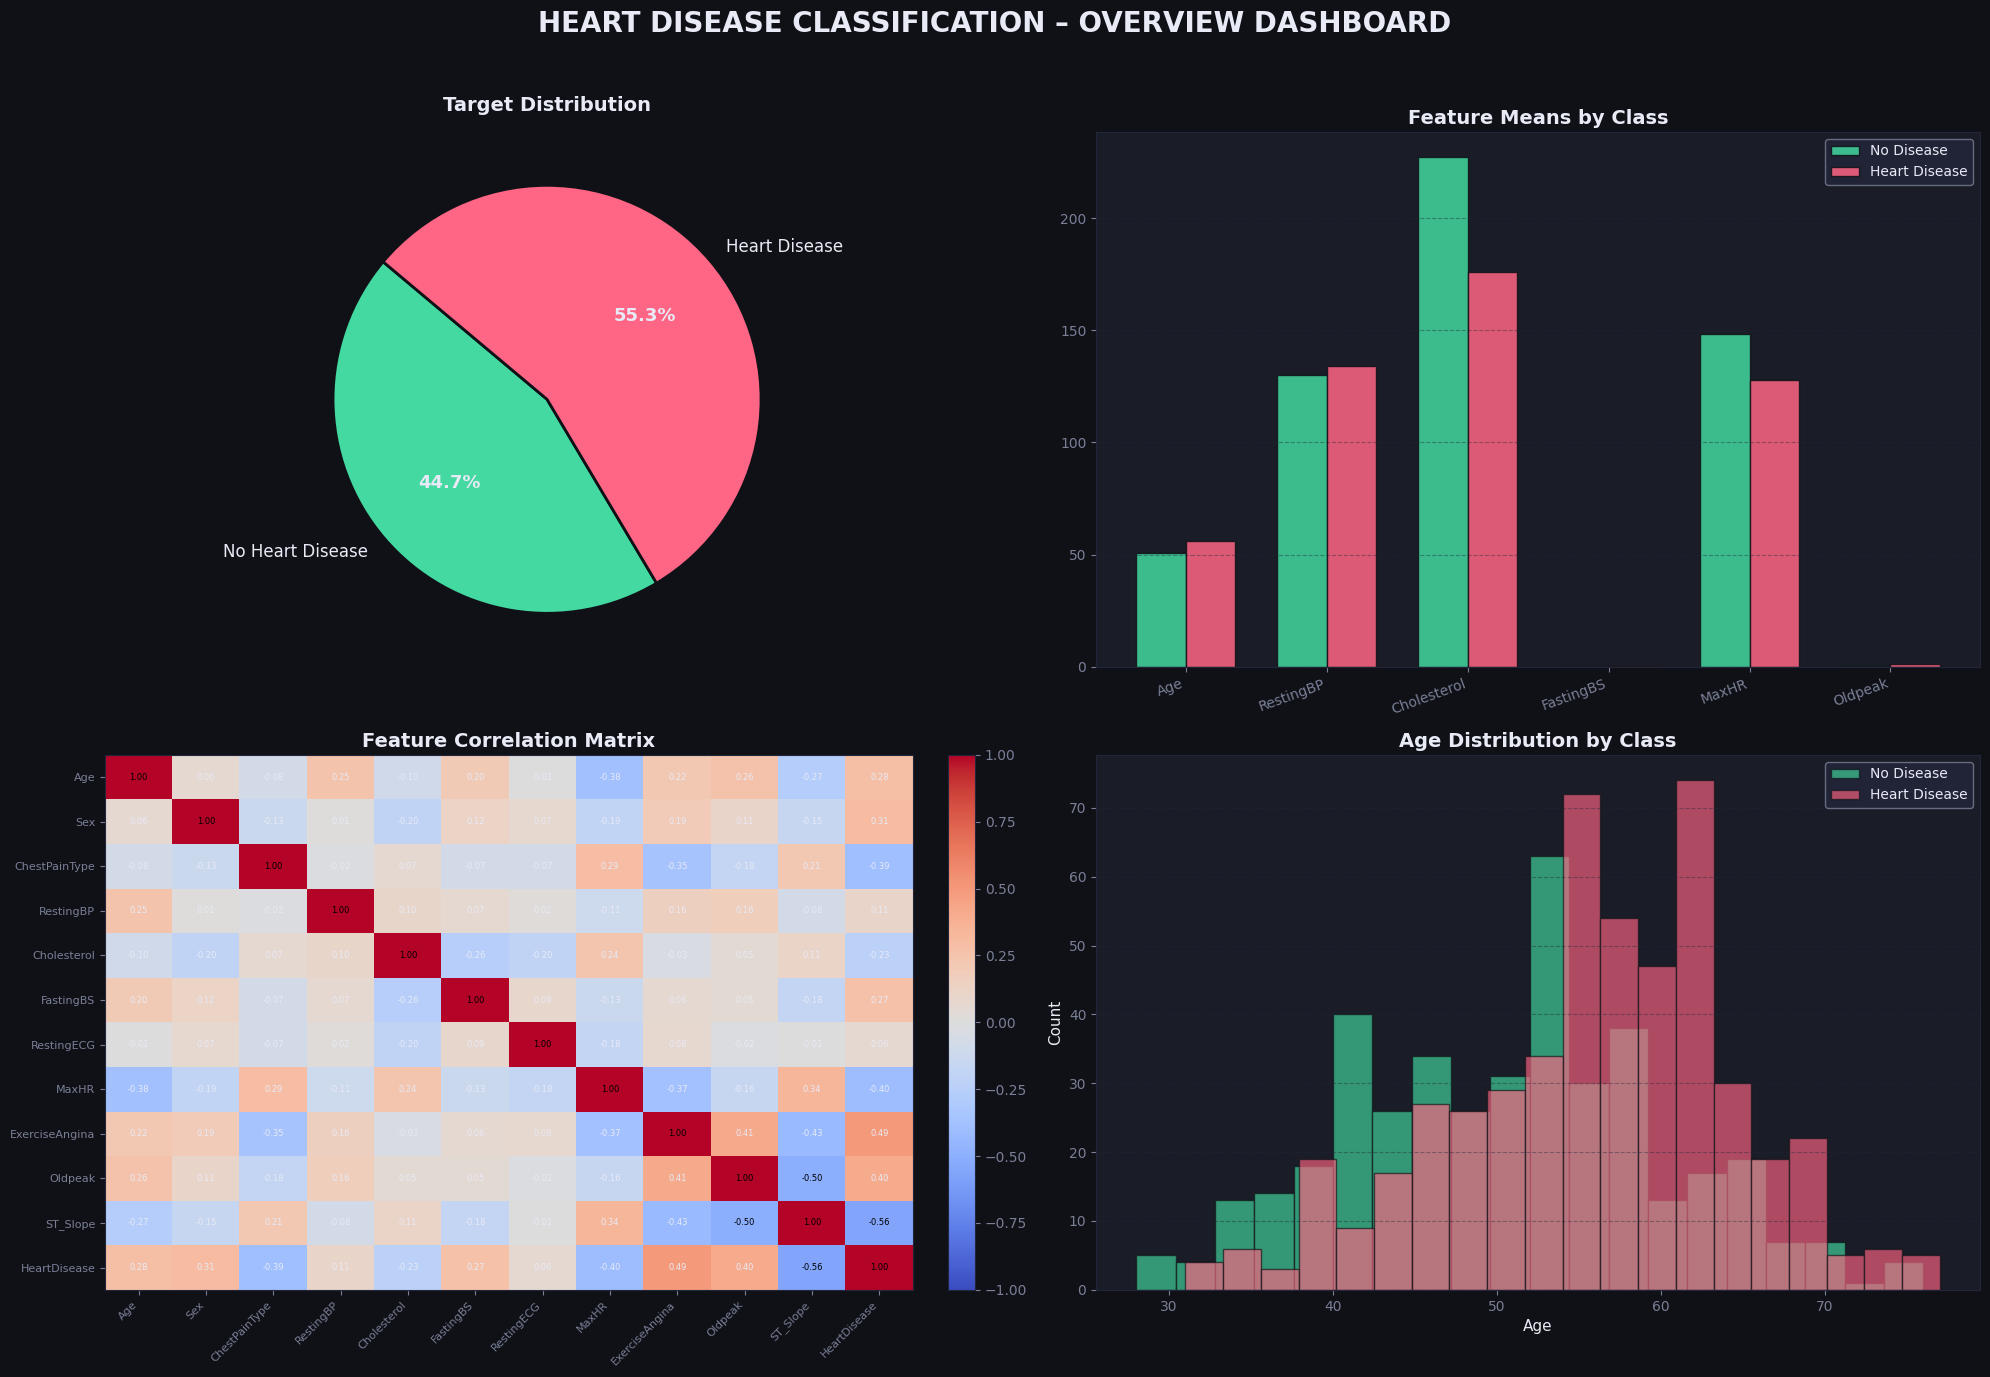

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4.  FIGURE 1 – OVERVIEW DASHBOARD
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig1, axes = plt.subplots(2, 2, figsize=(20, 14))
fig1.patch.set_facecolor(PALETTE["bg"])
fig1.suptitle("HEART DISEASE CLASSIFICATION – OVERVIEW DASHBOARD",
              fontsize=20, fontweight="bold", color=PALETTE["text"], y=0.98)

# ── 4a. Target Distribution
ax = axes[0, 0]
labels_dist = ["No Heart Disease", "Heart Disease"]
sizes = [( df.HeartDisease==0).sum(), (df.HeartDisease==1).sum()]
colors_dist = [PALETTE["accent3"], PALETTE["accent2"]]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels_dist, colors=colors_dist,
    autopct="%1.1f%%", startangle=140,
    wedgeprops=dict(edgecolor=PALETTE["bg"], linewidth=2),
    textprops=dict(color=PALETTE["text"], fontsize=12)
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight("bold")
ax.set_title("Target Distribution", fontsize=14, fontweight="bold", pad=15)

# ── 4b. Class balance per feature (top 4 numerics box)
ax = axes[0, 1]
feature_means = df_enc.groupby(target)[num_cols].mean()
x_pos = np.arange(len(num_cols))
w = 0.35
bars0 = ax.bar(x_pos - w/2, feature_means.loc[0], w, label="No Disease",
               color=PALETTE["accent3"], alpha=0.85, edgecolor=PALETTE["bg"])
bars1 = ax.bar(x_pos + w/2, feature_means.loc[1], w, label="Heart Disease",
               color=PALETTE["accent2"], alpha=0.85, edgecolor=PALETTE["bg"])
ax.set_xticks(x_pos)
ax.set_xticklabels(num_cols, rotation=20, ha="right")
ax.set_title("Feature Means by Class", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)

# ── 4c. Correlation Heatmap
ax = axes[1, 0]
corr = df_enc.corr()
n = len(corr)
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(n)); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(n):
    for j in range(n):
        val = corr.values[i, j]
        color = "black" if abs(val) > 0.5 else PALETTE["text"]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=color)
fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")

# ── 4d. Age Distribution
ax = axes[1, 1]
for cls, color, label in [(0, PALETTE["accent3"], "No Disease"),
                            (1, PALETTE["accent2"], "Heart Disease")]:
    subset = df[df.HeartDisease == cls]["Age"]
    ax.hist(subset, bins=20, alpha=0.65, color=color, label=label, edgecolor=PALETTE["bg"])
ax.set_xlabel("Age", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Age Distribution by Class", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.96])


1. Target Distribution

Grafik pie chart menunjukkan distribusi target pada dataset penyakit jantung. Sebanyak 55,3% data termasuk kategori Heart Disease, sedangkan 44,7% termasuk No Heart Disease. Hal ini menunjukkan bahwa dataset relatif seimbang meskipun jumlah penderita penyakit jantung sedikit lebih banyak dibandingkan yang tidak memiliki penyakit jantung.

2. Feature Means by Class

Grafik batang menampilkan rata-rata beberapa fitur berdasarkan kelas penyakit jantung dan tidak penyakit jantung. Kelompok penderita penyakit jantung cenderung memiliki rata-rata usia (Age) dan tekanan darah istirahat (RestingBP) yang lebih tinggi, sedangkan kelompok tanpa penyakit jantung memiliki rata-rata detak jantung maksimum (MaxHR) yang lebih besar. Selain itu, nilai Oldpeak pada penderita penyakit jantung terlihat lebih tinggi, yang mengindikasikan adanya perbedaan karakteristik antara kedua kelompok.

3. Feature Correlation Matrix

Heatmap korelasi menunjukkan hubungan antar variabel dalam dataset. Variabel HeartDisease memiliki korelasi positif cukup kuat dengan ExerciseAngina dan Oldpeak, serta korelasi negatif dengan ST_Slope dan MaxHR. Hal ini mengindikasikan bahwa beberapa fitur memiliki pengaruh yang cukup signifikan terhadap klasifikasi penyakit jantung dan dapat menjadi faktor penting dalam proses prediksi model machine learning.

4. Age Distribution by Class

Histogram distribusi usia menunjukkan bahwa penderita penyakit jantung lebih banyak berada pada rentang usia sekitar 50–65 tahun. Sementara itu, kelompok tanpa penyakit jantung lebih tersebar pada usia yang sedikit lebih muda. Grafik ini menunjukkan bahwa risiko penyakit jantung cenderung meningkat pada kelompok usia yang lebih tua.

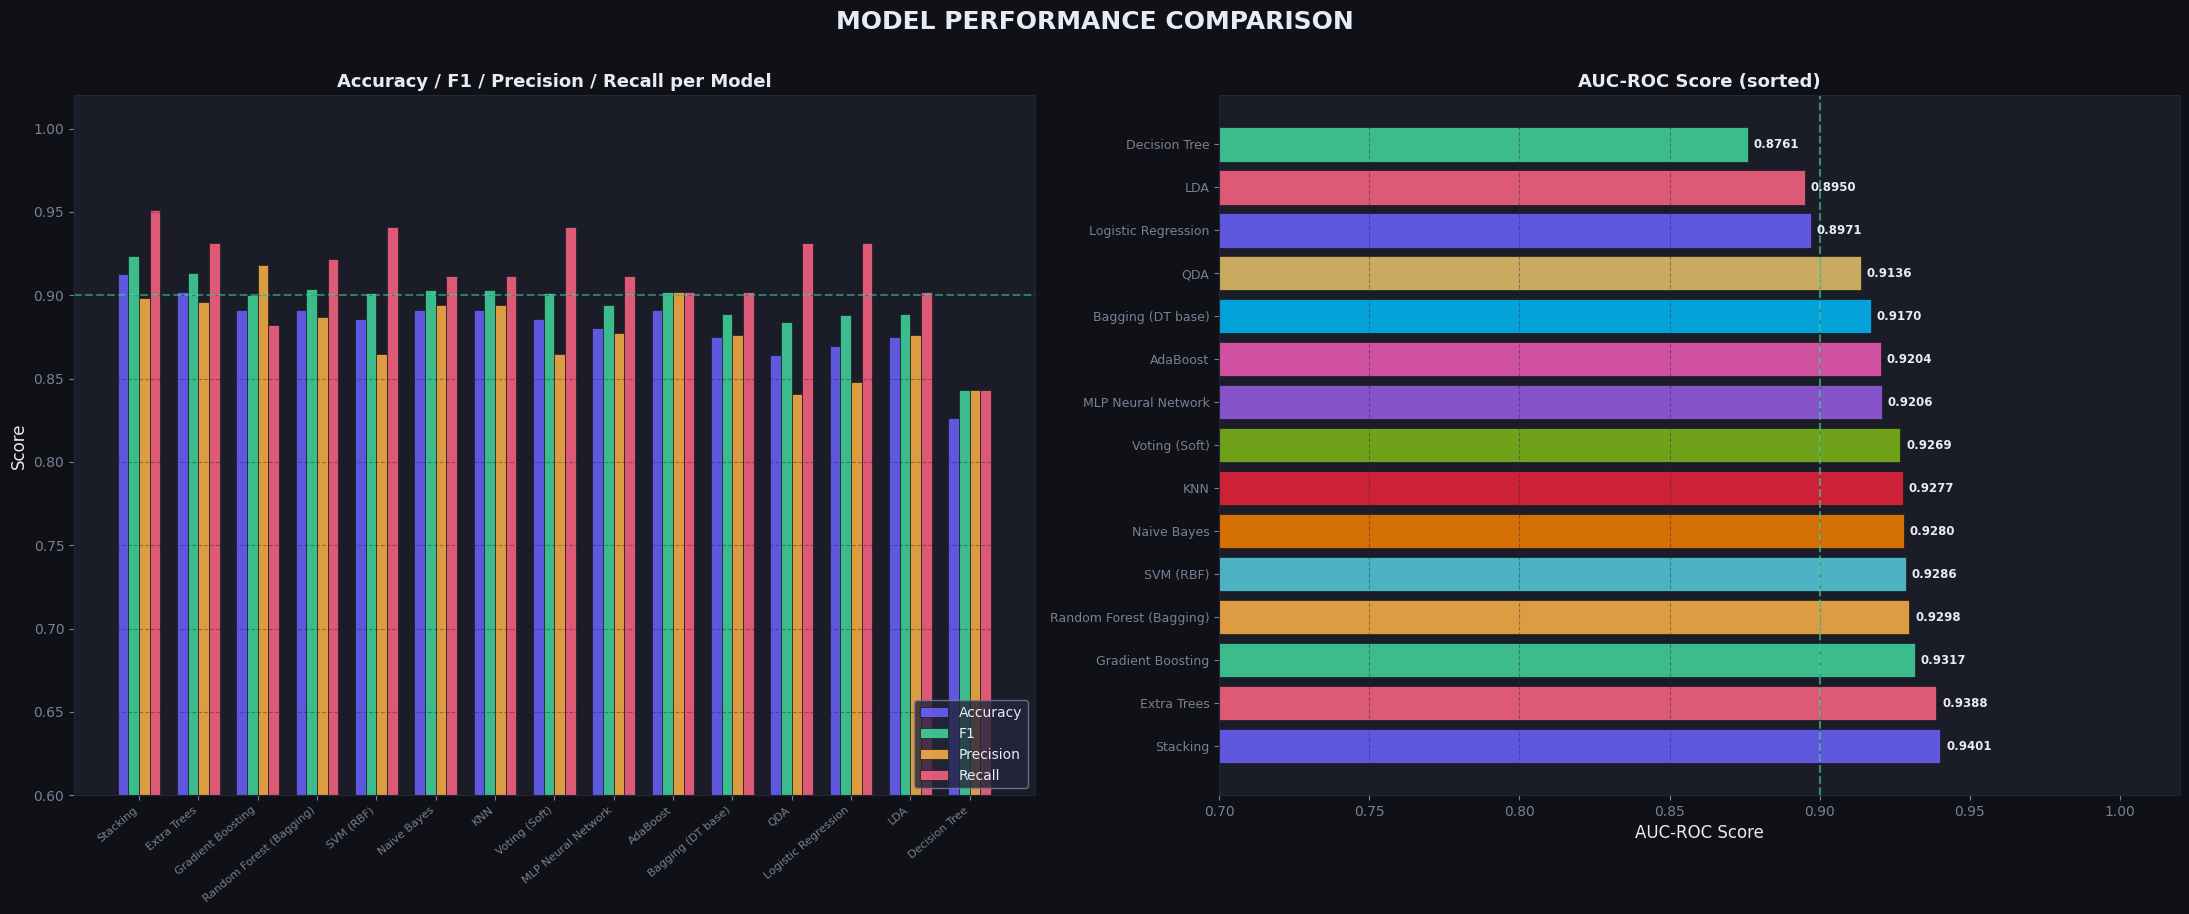

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 5.  FIGURE 2 – MODEL COMPARISON
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig2, axes2 = plt.subplots(1, 2, figsize=(22, 9))
fig2.patch.set_facecolor(PALETTE["bg"])
fig2.suptitle("MODEL PERFORMANCE COMPARISON", fontsize=18, fontweight="bold",
              color=PALETTE["text"], y=1.01)

model_names = df_res["Model"].tolist()
colors_bar  = [MODEL_COLORS[i % len(MODEL_COLORS)] for i in range(len(model_names))]

# ── 5a. Multi-metric grouped bar
ax = axes2[0]
metrics = ["Accuracy", "F1", "Precision", "Recall"]
x = np.arange(len(model_names))
w_bar = 0.18
metric_colors = [PALETTE["accent1"], PALETTE["accent3"], PALETTE["accent4"], PALETTE["accent2"]]

for i, (metric, mc) in enumerate(zip(metrics, metric_colors)):
    vals = df_res[metric].tolist()
    bars = ax.bar(x + (i - 1.5) * w_bar, vals, w_bar, label=metric,
                  color=mc, alpha=0.85, edgecolor=PALETTE["bg"], linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=40, ha="right", fontsize=8)
ax.set_ylim(0.6, 1.02)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Accuracy / F1 / Precision / Recall per Model", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.4)
ax.axhline(0.9, color=PALETTE["accent3"], linestyle="--", alpha=0.5, linewidth=1.5,
           label="0.9 threshold")

# ── 5b. AUC-ROC horizontal bar
ax = axes2[1]
auc_vals   = []
auc_names  = []
for _, row in df_res.iterrows():
    if row["AUC-ROC"] != "-":
        auc_vals.append(float(row["AUC-ROC"]))
        auc_names.append(row["Model"])

y_pos = np.arange(len(auc_names))
bar_colors = [MODEL_COLORS[i % len(MODEL_COLORS)] for i in range(len(auc_names))]
hbars = ax.barh(y_pos, auc_vals, color=bar_colors, alpha=0.85,
                edgecolor=PALETTE["bg"], linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(auc_names, fontsize=9)
ax.set_xlim(0.7, 1.02)
ax.set_xlabel("AUC-ROC Score", fontsize=12)
ax.set_title("AUC-ROC Score (sorted)", fontsize=13, fontweight="bold")
ax.axvline(0.9, color=PALETTE["accent3"], linestyle="--", alpha=0.6, linewidth=1.5)
for bar, val in zip(hbars, auc_vals):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8.5, fontweight="bold",
            color=PALETTE["text"])
ax.grid(axis="x", alpha=0.4)

plt.tight_layout()


1. Accuracy / F1 / Precision / Recall per Model

Grafik batang sebelah kiri menunjukkan perbandingan performa berbagai model klasifikasi berdasarkan metrik Accuracy, F1-Score, Precision, dan Recall. Secara umum, model ensemble seperti Stacking, Extra Trees, dan Gradient Boosting memiliki performa paling baik dengan nilai metrik yang relatif tinggi dan stabil di sekitar atau di atas 0,90. Model seperti Decision Tree memiliki performa paling rendah dibanding model lainnya, sedangkan model ensemble dan neural network menunjukkan keseimbangan yang baik antara precision dan recall sehingga lebih efektif dalam mendeteksi penyakit jantung.

2. AUC-ROC Score (sorted)

Grafik batang horizontal sebelah kanan menampilkan perbandingan nilai AUC-ROC dari setiap model yang telah diurutkan dari terendah hingga tertinggi. Model Stacking memperoleh nilai AUC-ROC tertinggi sekitar 0,9401, diikuti oleh Extra Trees dan Gradient Boosting, yang menunjukkan kemampuan sangat baik dalam membedakan kelas penyakit jantung dan non-penyakit jantung. Sementara itu, Decision Tree memiliki nilai AUC-ROC paling rendah yaitu sekitar 0,8761. Secara keseluruhan, model ensemble terbukti memberikan performa yang lebih unggul dibanding model klasifikasi sederhana.

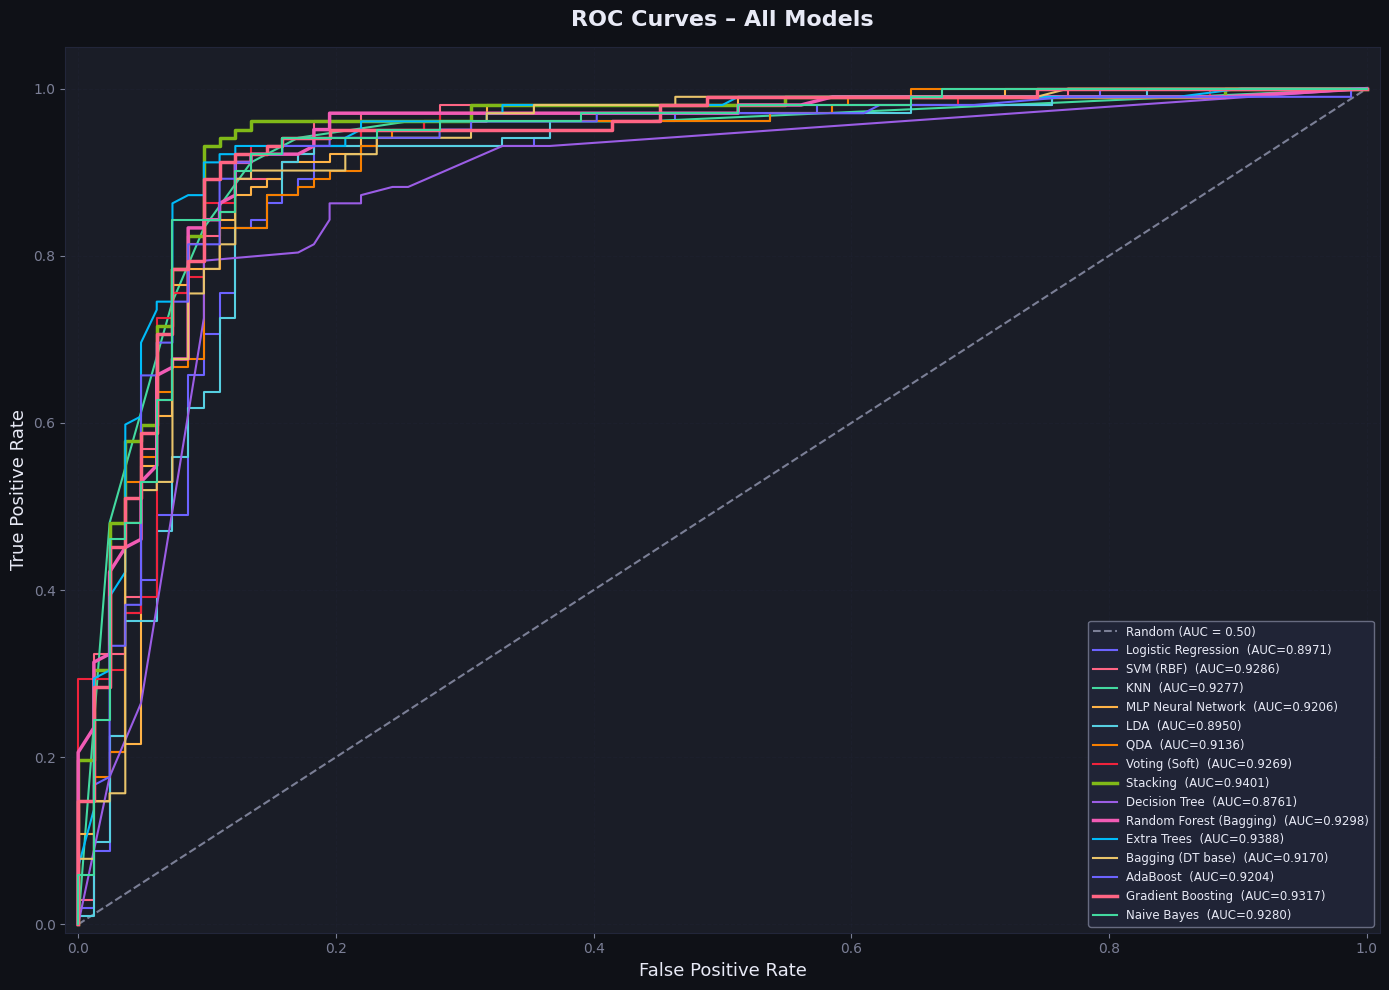

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 6.  FIGURE 3 – ROC CURVES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig3, ax3 = plt.subplots(figsize=(14, 10))
fig3.patch.set_facecolor(PALETTE["bg"])
ax3.set_facecolor(PALETTE["surface"])

ax3.plot([0,1],[0,1], color=PALETTE["muted"], linestyle="--", linewidth=1.5,
         label="Random (AUC = 0.50)")

for i, row in enumerate(results):
    if row["_y_prob"] is not None:
        fpr, tpr, _ = roc_curve(y_test, row["_y_prob"])
        auc_val = roc_auc_score(y_test, row["_y_prob"])
        color = MODEL_COLORS[i % len(MODEL_COLORS)]
        lw = 2.5 if row["Model"] in ["Stacking","Gradient Boosting","Random Forest (Bagging)"] else 1.5
        ax3.plot(fpr, tpr, color=color, linewidth=lw,
                 label=f"{row['Model']}  (AUC={auc_val:.4f})")

ax3.set_xlabel("False Positive Rate", fontsize=13)
ax3.set_ylabel("True Positive Rate", fontsize=13)
ax3.set_title("ROC Curves – All Models", fontsize=16, fontweight="bold", pad=15)
ax3.legend(fontsize=8.5, loc="lower right", framealpha=0.8)
ax3.grid(alpha=0.3)
ax3.set_xlim(-0.01, 1.01)
ax3.set_ylim(-0.01, 1.05)

plt.tight_layout()


Grafik ROC Curve menampilkan perbandingan kemampuan seluruh model klasifikasi dalam membedakan kelas penyakit jantung dan non-penyakit jantung berdasarkan hubungan antara True Positive Rate dan False Positive Rate. Semakin dekat kurva ke sudut kiri atas, maka semakin baik performa model tersebut. Berdasarkan grafik, model ensemble seperti Stacking, Extra Trees, dan Gradient Boosting memiliki kurva ROC yang paling baik dengan nilai AUC mendekati 1, yang menunjukkan kemampuan klasifikasi yang sangat tinggi. Sebaliknya, Decision Tree dan Logistic Regression memiliki performa yang relatif lebih rendah dibanding model lainnya. Garis diagonal putus-putus menunjukkan performa klasifikasi acak (random classifier) dengan nilai AUC sebesar 0,50 sehingga seluruh model pada grafik memiliki performa yang jauh lebih baik dibanding prediksi acak.

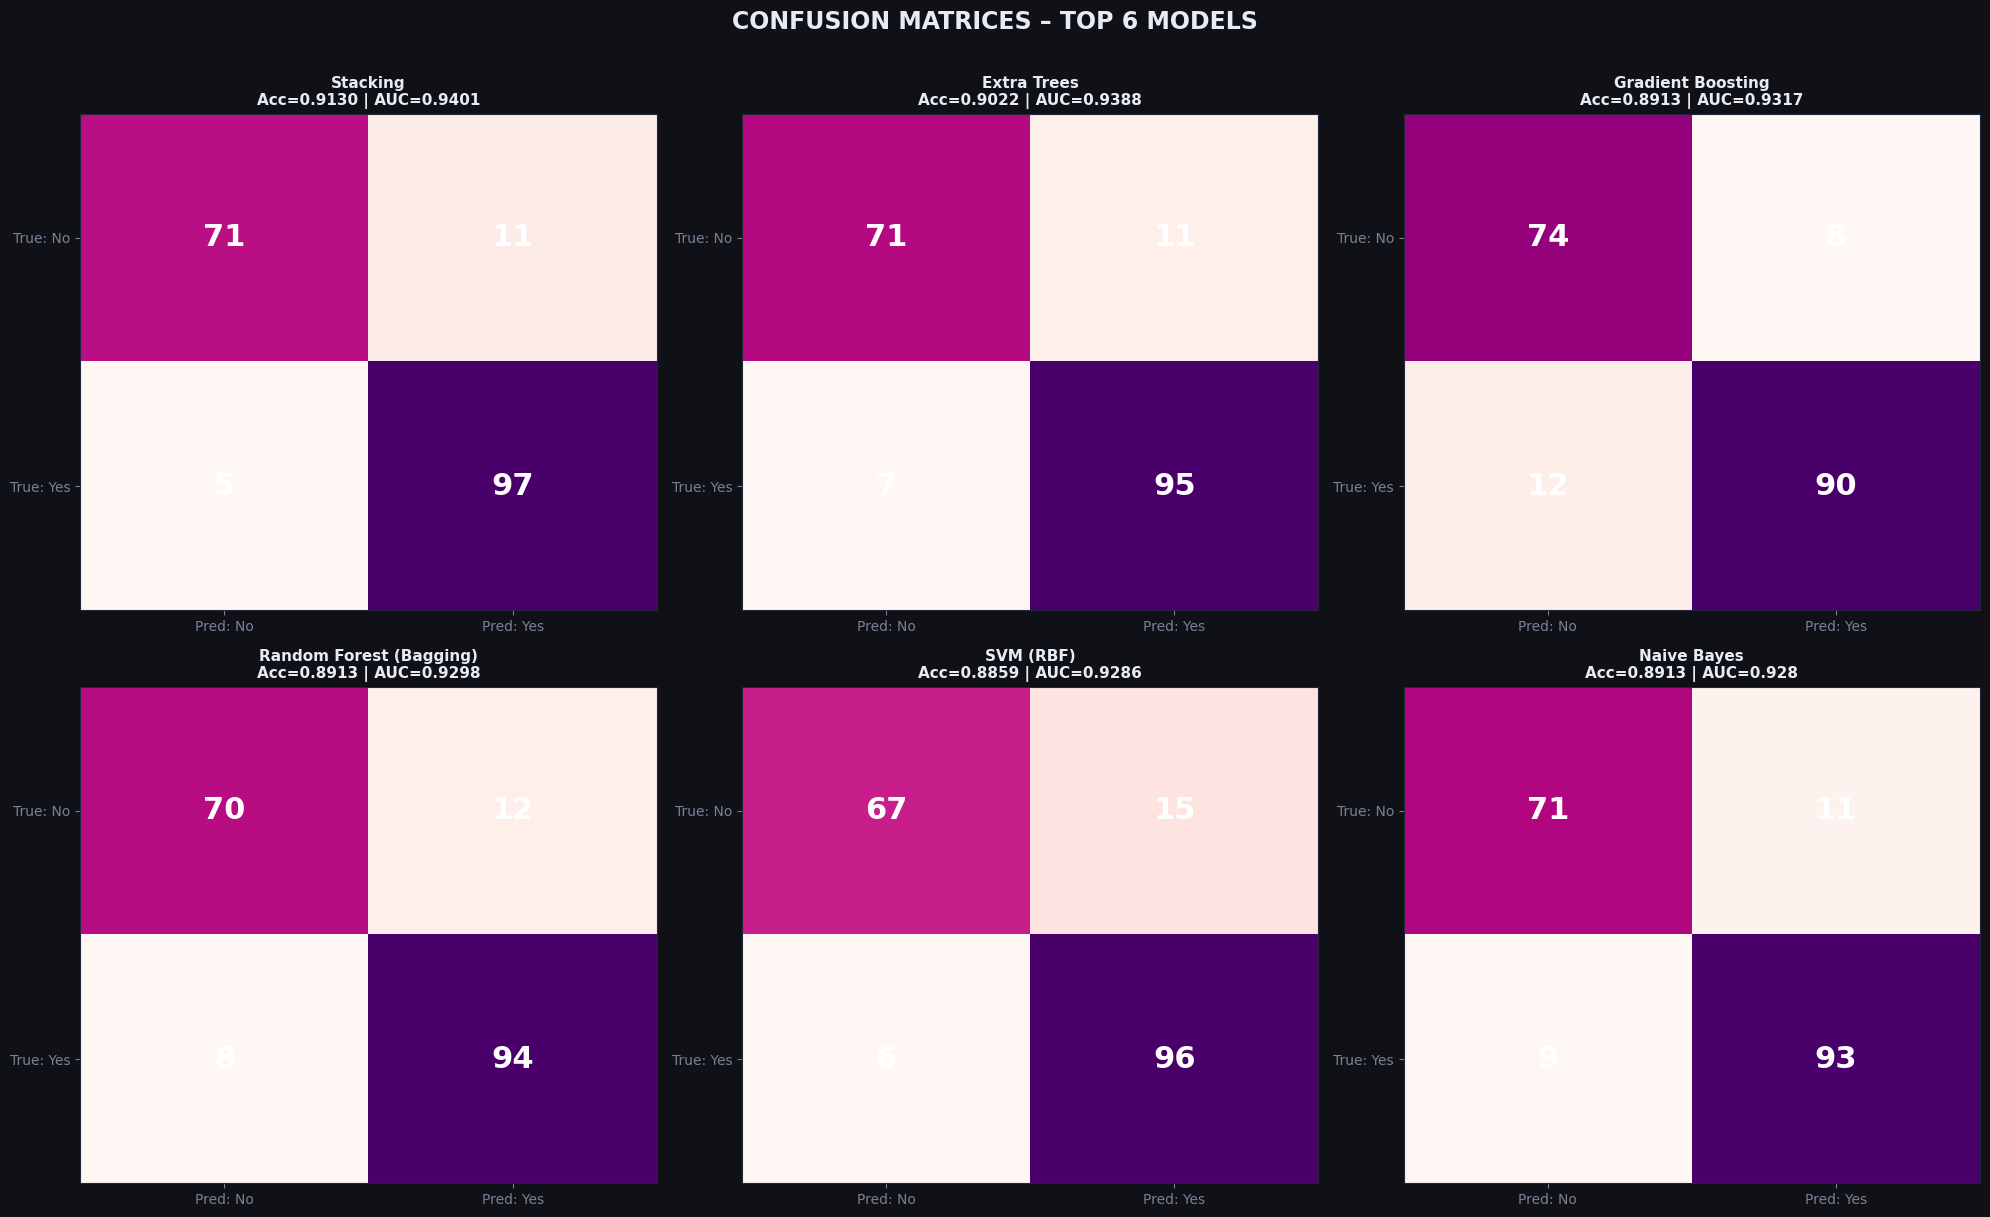

In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 7.  FIGURE 4 – CONFUSION MATRICES (top 6)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
top6 = df_res.head(6)["Model"].tolist()
fig4, axes4 = plt.subplots(2, 3, figsize=(20, 12))
fig4.patch.set_facecolor(PALETTE["bg"])
fig4.suptitle("CONFUSION MATRICES – TOP 6 MODELS", fontsize=17, fontweight="bold",
              color=PALETTE["text"], y=1.01)

row_map = {r["Model"]: r for r in results}
for idx, name in enumerate(top6):
    row_data = row_map[name]
    ax = axes4[idx // 3][idx % 3]
    cm_val = confusion_matrix(y_test, row_data["_y_pred"])
    im = ax.imshow(cm_val, cmap="RdPu", aspect="auto")
    for ii in range(2):
        for jj in range(2):
            ax.text(jj, ii, str(cm_val[ii, jj]), ha="center", va="center",
                    fontsize=22, fontweight="bold", color="white")
    ax.set_xticks([0,1]); ax.set_xticklabels(["Pred: No","Pred: Yes"], fontsize=10)
    ax.set_yticks([0,1]); ax.set_yticklabels(["True: No","True: Yes"], fontsize=10)
    acc_v = accuracy_score(y_test, row_data["_y_pred"])
    auc_v = row_data["AUC-ROC"]
    ax.set_title(f"{name}\nAcc={acc_v:.4f} | AUC={auc_v}", fontsize=11, fontweight="bold")

plt.tight_layout()

Gambar tersebut menampilkan confusion matrix dari enam model klasifikasi terbaik dalam prediksi penyakit jantung, yaitu Stacking, Extra Trees, Gradient Boosting, Random Forest (Bagging), SVM (RBF), dan Naive Bayes. Setiap confusion matrix menunjukkan jumlah prediksi benar dan salah untuk kelas “No Heart Disease” dan “Heart Disease”. Model Stacking memiliki performa terbaik dengan nilai Accuracy sebesar 0,9130 dan AUC sebesar 0,9401, ditunjukkan oleh jumlah prediksi benar yang tinggi yaitu 71 data negatif dan 97 data positif dengan kesalahan klasifikasi yang relatif sedikit. Model ensemble seperti Extra Trees, Gradient Boosting, dan Random Forest juga menunjukkan performa yang sangat baik dengan jumlah false positive dan false negative yang rendah. Sementara itu, SVM dan Naive Bayes tetap memberikan hasil yang cukup baik meskipun memiliki kesalahan prediksi sedikit lebih besar dibanding model ensemble. Secara keseluruhan, gambar ini menunjukkan bahwa model ensemble cenderung memberikan hasil klasifikasi yang lebih akurat dan stabil pada dataset penyakit jantung.

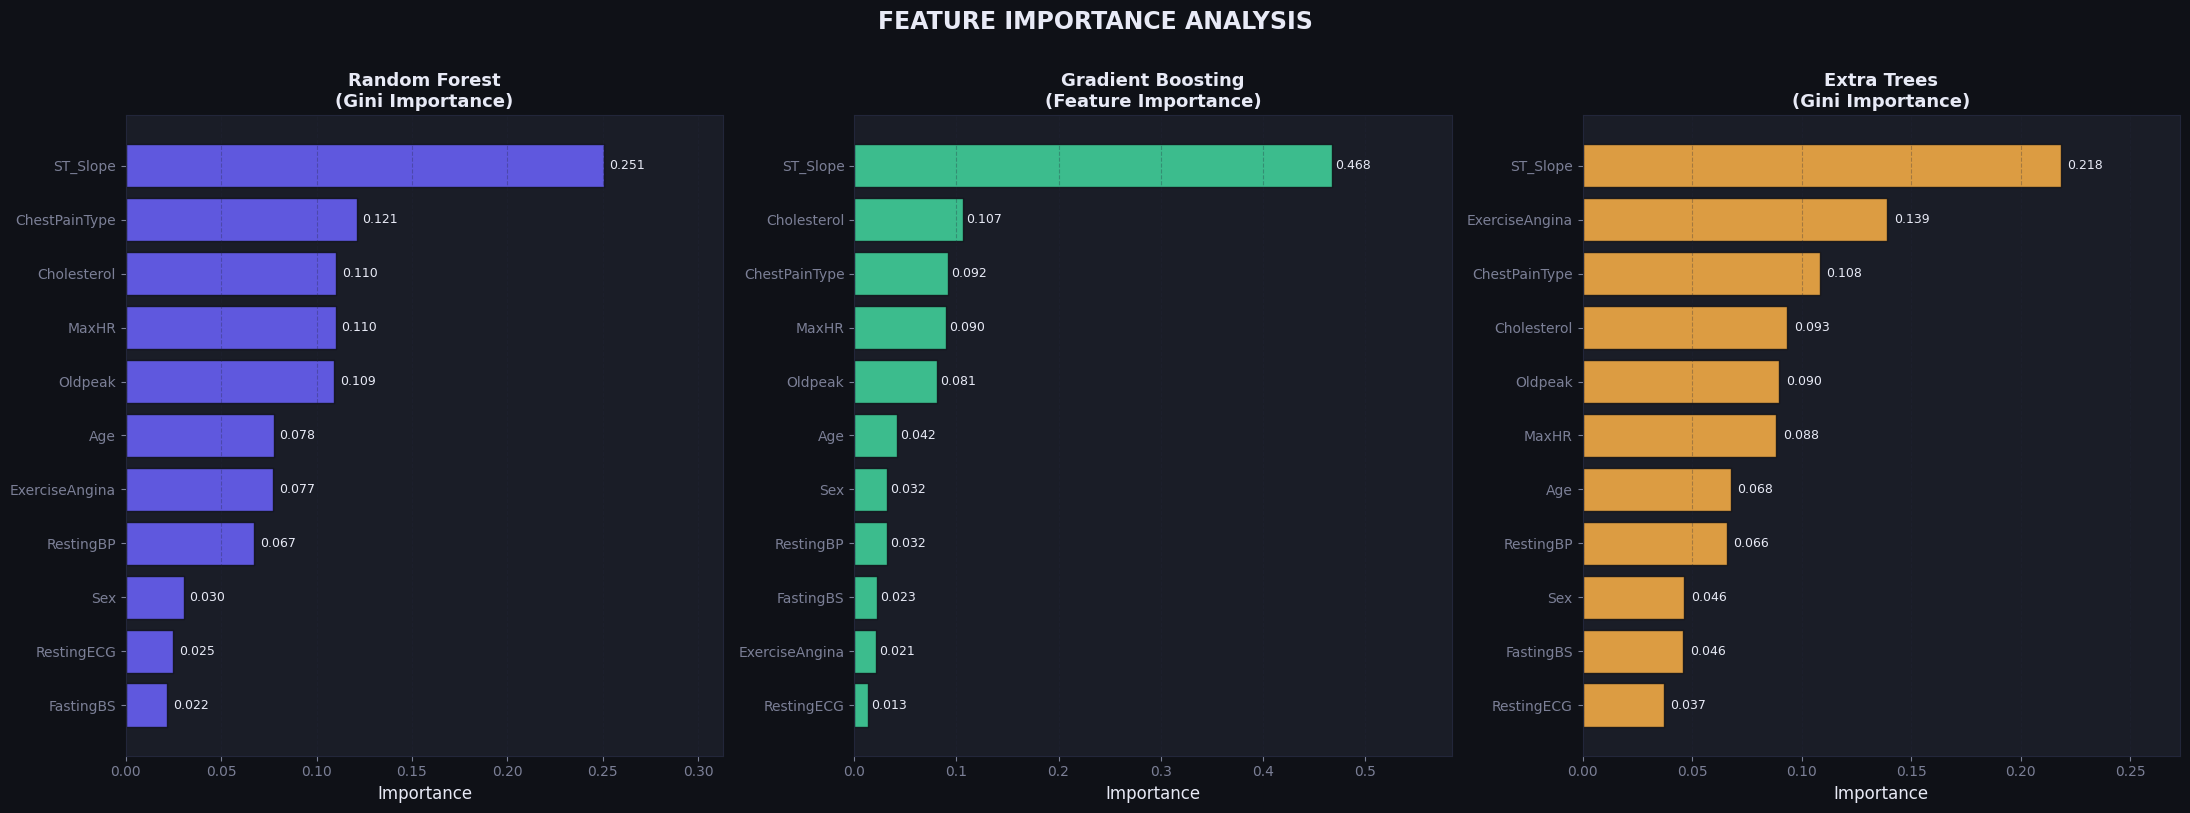

In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 8.  FIGURE 5 – FEATURE IMPORTANCE (RF + GB + Permutation)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
feature_names = list(X.columns)

rf_model  = trained_models["Random Forest (Bagging)"][0]
gb_model  = trained_models["Gradient Boosting"][0]
et_model  = trained_models["Extra Trees"][0]

fig5, axes5 = plt.subplots(1, 3, figsize=(22, 8))
fig5.patch.set_facecolor(PALETTE["bg"])
fig5.suptitle("FEATURE IMPORTANCE ANALYSIS", fontsize=17, fontweight="bold",
              color=PALETTE["text"], y=1.01)

for ax, model, title, color in [
    (axes5[0], rf_model, "Random Forest\n(Gini Importance)", PALETTE["accent1"]),
    (axes5[1], gb_model, "Gradient Boosting\n(Feature Importance)", PALETTE["accent3"]),
    (axes5[2], et_model, "Extra Trees\n(Gini Importance)", PALETTE["accent4"]),
]:
    fi = model.feature_importances_
    sorted_idx = np.argsort(fi)
    bars = ax.barh(
        [feature_names[i] for i in sorted_idx], fi[sorted_idx],
        color=color, alpha=0.85, edgecolor=PALETTE["bg"]
    )
    for bar, val in zip(bars, fi[sorted_idx]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9, color=PALETTE["text"])
    ax.set_xlabel("Importance", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(0, fi.max() * 1.25)

plt.tight_layout()

Grafik Feature Importance Analysis menunjukkan tingkat pengaruh setiap variabel terhadap prediksi penyakit jantung pada tiga model ensemble, yaitu Random Forest, Gradient Boosting, dan Extra Trees. Secara umum, variabel ST_Slope menjadi fitur paling penting pada ketiga model dengan nilai importance tertinggi, terutama pada Gradient Boosting yang mencapai sekitar 0,468. Selain itu, fitur seperti ChestPainType, Cholesterol, Oldpeak, dan MaxHR juga memiliki kontribusi cukup besar dalam proses klasifikasi. Pada model Extra Trees, variabel ExerciseAngina terlihat memiliki pengaruh lebih tinggi dibanding model lainnya. Sementara itu, fitur seperti RestingECG, Sex, dan FastingBS memiliki nilai importance paling rendah sehingga kontribusinya terhadap prediksi relatif kecil. Grafik ini menunjukkan bahwa beberapa variabel medis tertentu memiliki peran dominan dalam mendeteksi risiko penyakit jantung.

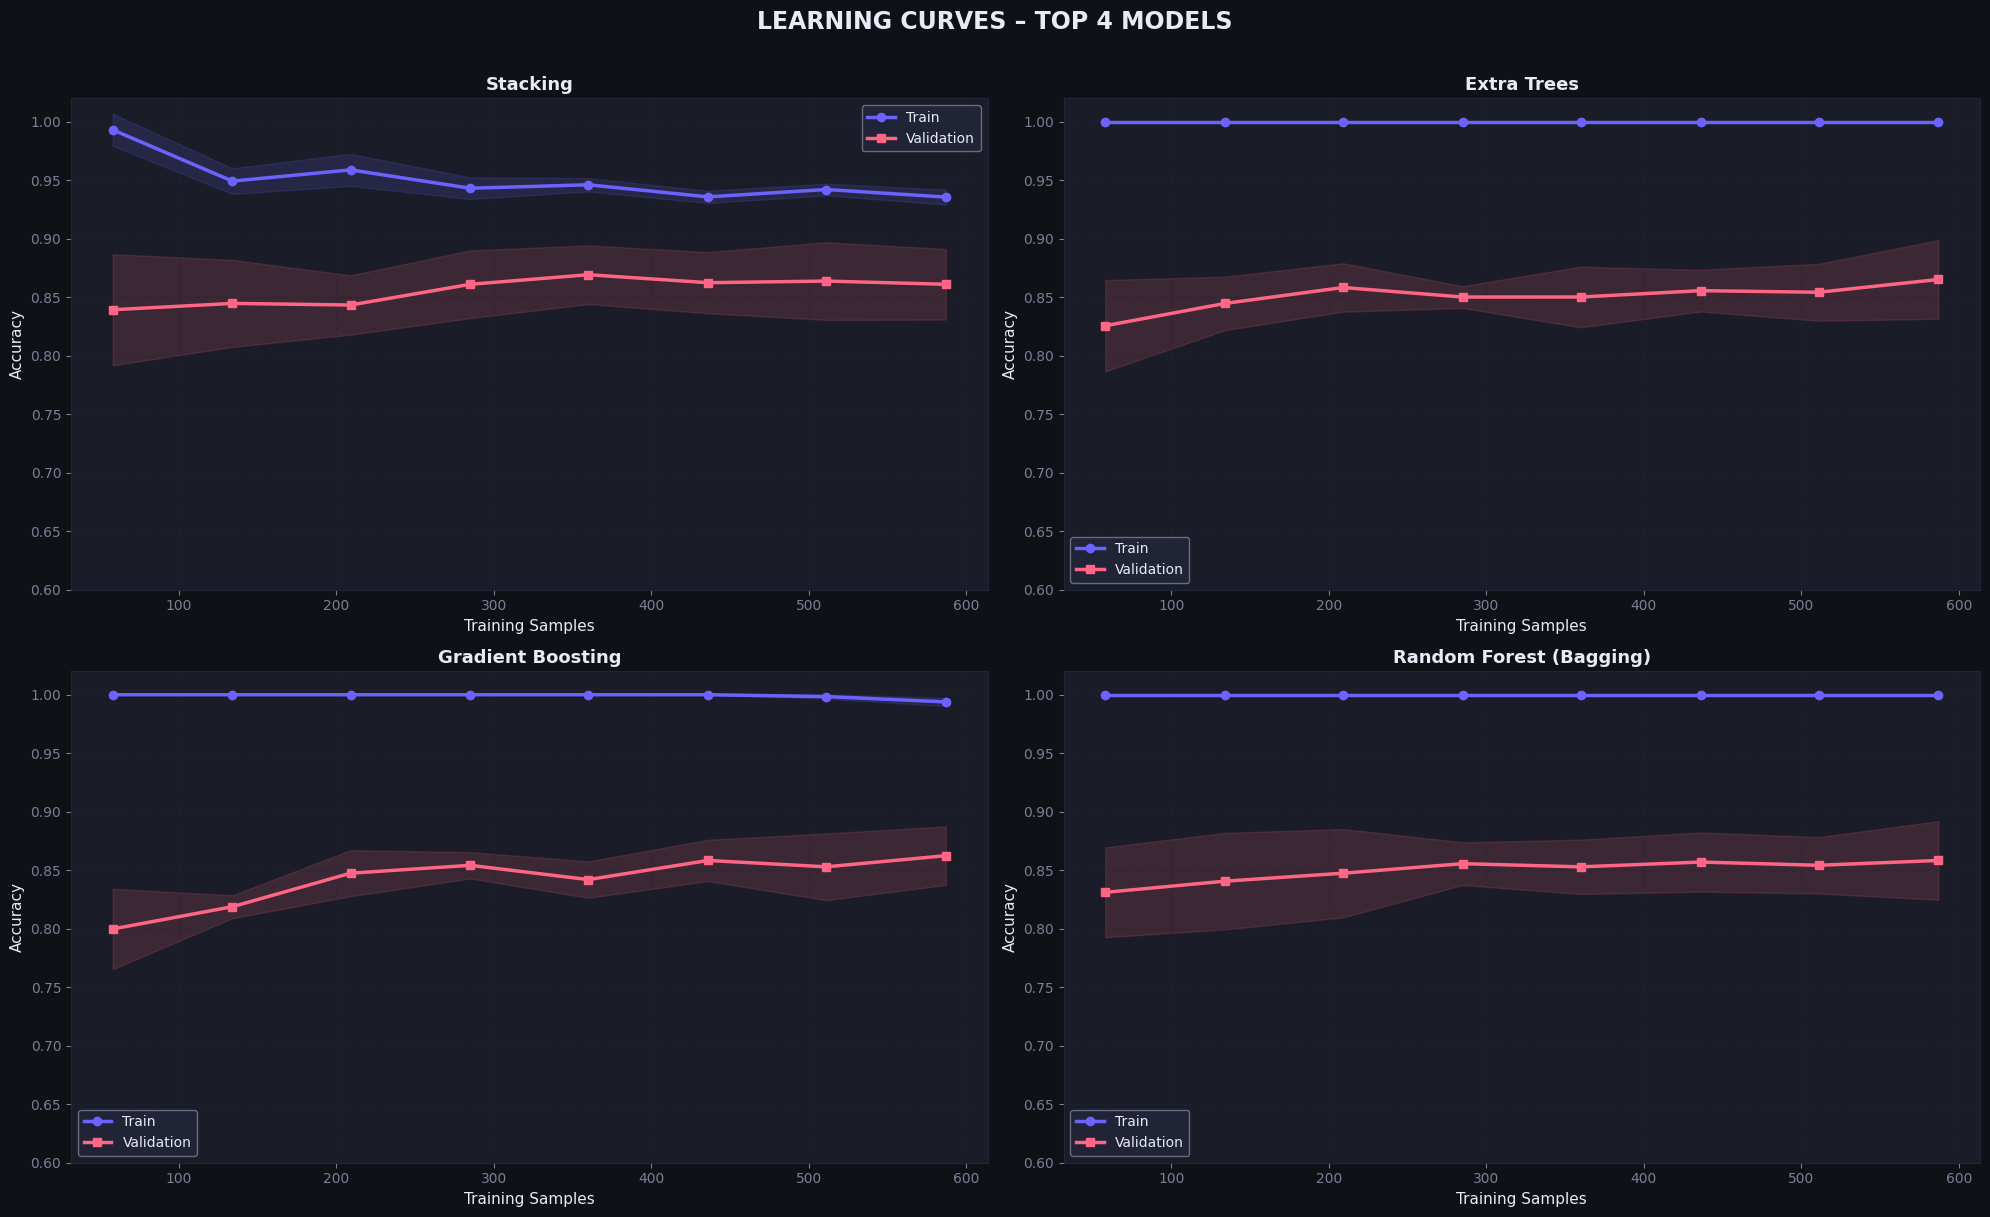

In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 9.  FIGURE 6 – LEARNING CURVES (top 4 models)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
top4 = df_res.head(4)["Model"].tolist()
fig6, axes6 = plt.subplots(2, 2, figsize=(20, 12))
fig6.patch.set_facecolor(PALETTE["bg"])
fig6.suptitle("LEARNING CURVES – TOP 4 MODELS", fontsize=17, fontweight="bold",
              color=PALETTE["text"], y=1.01)

for idx, name in enumerate(top4):
    ax = axes6[idx // 2][idx % 2]
    model_obj, use_sc = trained_models[name]
    Xcv = X_train_sc if use_sc else np.array(X_train)
    ycv = np.array(y_train)

    train_sizes, train_scores, val_scores = learning_curve(
        model_obj, Xcv, ycv,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 8), scoring="accuracy"
    )
    ts_mean = train_scores.mean(axis=1)
    ts_std  = train_scores.std(axis=1)
    vs_mean = val_scores.mean(axis=1)
    vs_std  = val_scores.std(axis=1)

    ax.fill_between(train_sizes, ts_mean - ts_std, ts_mean + ts_std,
                    alpha=0.15, color=PALETTE["accent1"])
    ax.fill_between(train_sizes, vs_mean - vs_std, vs_mean + vs_std,
                    alpha=0.15, color=PALETTE["accent2"])
    ax.plot(train_sizes, ts_mean, "o-", color=PALETTE["accent1"],
            linewidth=2.5, markersize=6, label="Train")
    ax.plot(train_sizes, vs_mean, "s-", color=PALETTE["accent2"],
            linewidth=2.5, markersize=6, label="Validation")
    ax.set_xlabel("Training Samples", fontsize=11)
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.4)
    ax.set_ylim(0.6, 1.02)

plt.tight_layout()

Grafik di atas menampilkan learning curves dari empat model terbaik yaitu Stacking, Extra Trees, Gradient Boosting, dan Random Forest (Bagging) yang memvisualisasikan hubungan antara jumlah data training dengan akurasi pada set training maupun validasi. Terlihat jelas bahwa ketiga model berbasis pohon (Extra Trees, Gradient Boosting, dan Random Forest) menunjukkan pola yang hampir identik: kurva training mencapai akurasi sempurna (1.00) sejak awal dan tetap stagnan di sana, sementara kurva validasi berada jauh di bawahnya pada kisaran 0.82–0.87. Kesenjangan yang lebar dan konsisten ini merupakan indikasi kuat adanya overfitting model terlalu "menghafal" data training sehingga kemampuan generalisasinya terbatas. Model Stacking menunjukkan perilaku sedikit berbeda: kurva training-nya turun secara bertahap dari ~0.99 menuju ~0.93, yang berarti meta-learner (Logistic Regression) memberikan efek regularisasi sehingga model tidak sepenuhnya overfit.

Dari sisi kurva validasi, semua model menunjukkan tren yang positif meski landai, akurasi validasi secara umum meningkat seiring bertambahnya jumlah data training, namun kenaikannya tidak dramatis. Hal ini mengindikasikan bahwa penambahan data baru berpotensi meningkatkan performa, namun dataset saat ini (±600 sampel training) kemungkinan sudah mendekati titik jenuh untuk arsitektur model yang digunakan. Model Stacking memiliki gap train–validasi yang paling kecil di antara keempatnya, menjadikannya model dengan bias-variance trade-off paling seimbang, sekaligus menjelaskan mengapa ia tampil sebagai model terbaik secara keseluruhan dengan AUC-ROC 0.9401. Untuk meningkatkan performa lebih lanjut, pendekatan yang disarankan adalah menambah volume data, menerapkan teknik regularisasi lebih agresif (misalnya pruning, max_depth), atau menggunakan cross-validation yang lebih ketat dalam proses hyperparameter tuning.


Re-running CV for distribution plot ...


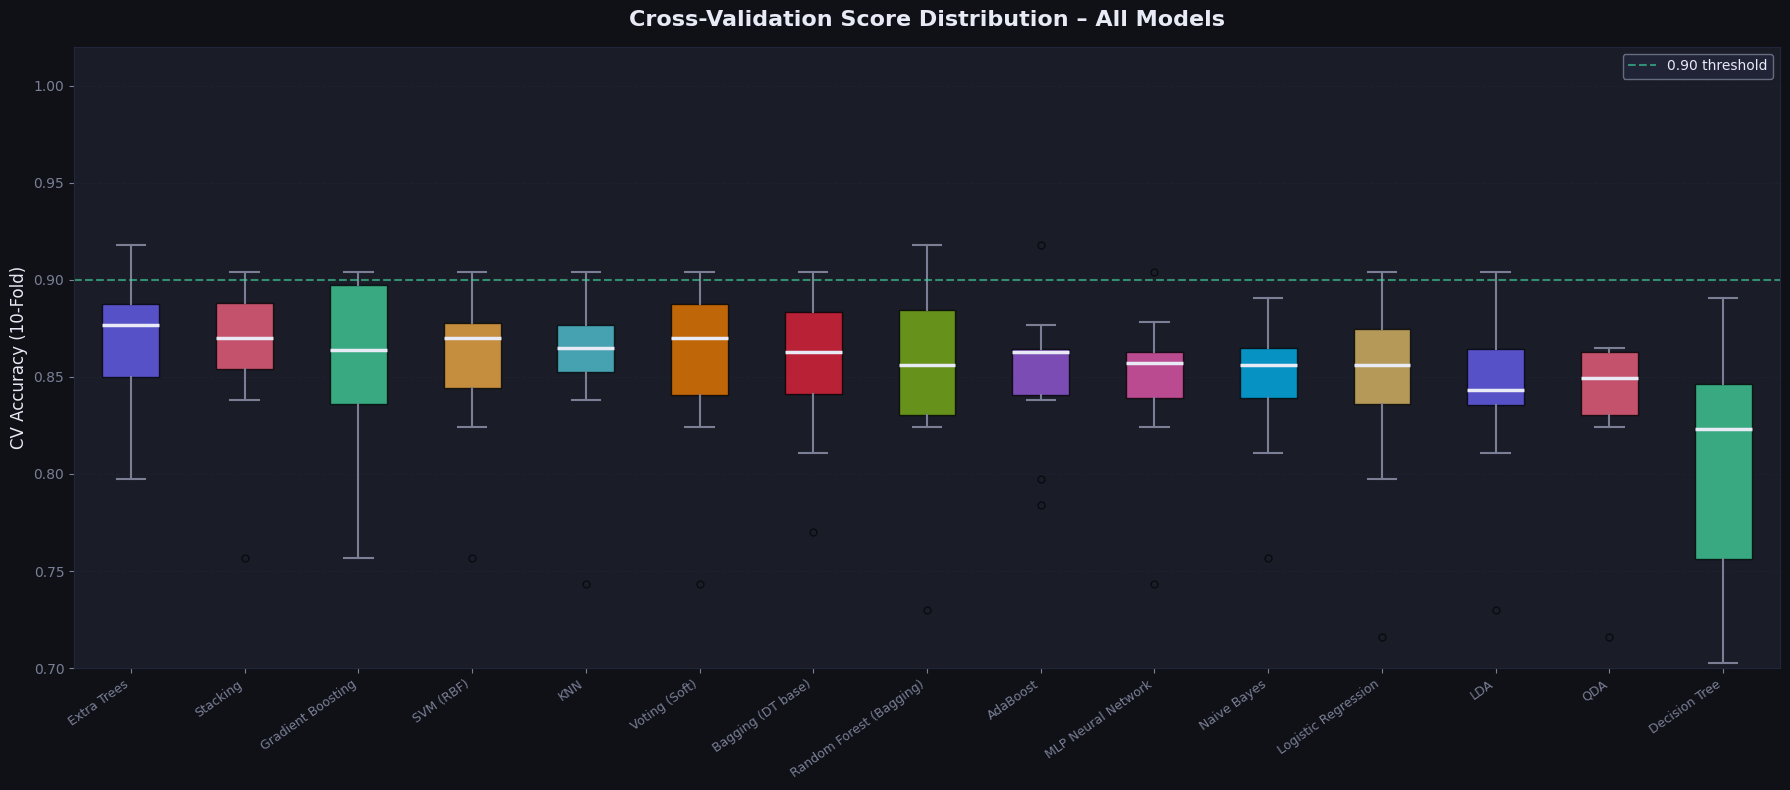

In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 10. FIGURE 7 – CV SCORE DISTRIBUTION (box plot)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\nRe-running CV for distribution plot ...")
cv_data = {}
for name, model in ALL_MODELS:
    use_sc = any(name == n for n, _ in MODELS_SCALED)
    Xcv = X_train_sc if use_sc else np.array(X_train)
    scores = cross_val_score(model, Xcv, y_train,
                             cv=StratifiedKFold(10, shuffle=True, random_state=42),
                             scoring="accuracy", n_jobs=-1)
    cv_data[name] = scores

sorted_names = sorted(cv_data.keys(), key=lambda n: cv_data[n].mean(), reverse=True)
cv_arrays = [cv_data[n] for n in sorted_names]
colors_box = [MODEL_COLORS[i % len(MODEL_COLORS)] for i in range(len(sorted_names))]

fig7, ax7 = plt.subplots(figsize=(18, 8))
fig7.patch.set_facecolor(PALETTE["bg"])
ax7.set_facecolor(PALETTE["surface"])

bp = ax7.boxplot(cv_arrays, patch_artist=True, notch=False,
                  medianprops=dict(color=PALETTE["text"], linewidth=2.5),
                  flierprops=dict(marker="o", markersize=5, alpha=0.6))
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for whisker in bp["whiskers"]:
    whisker.set(color=PALETTE["muted"], linewidth=1.5)
for cap in bp["caps"]:
    cap.set(color=PALETTE["muted"], linewidth=1.5)

ax7.set_xticks(range(1, len(sorted_names)+1))
ax7.set_xticklabels(sorted_names, rotation=35, ha="right", fontsize=9)
ax7.set_ylabel("CV Accuracy (10-Fold)", fontsize=12)
ax7.set_title("Cross-Validation Score Distribution – All Models",
              fontsize=16, fontweight="bold", pad=15)
ax7.axhline(0.9, color=PALETTE["accent3"], linestyle="--", alpha=0.6, linewidth=1.5,
            label="0.90 threshold")
ax7.legend(fontsize=10)
ax7.grid(axis="y", alpha=0.4)
ax7.set_ylim(0.7, 1.02)

plt.tight_layout()

Grafik boxplot di atas menyajikan distribusi akurasi 10-fold cross-validation dari 15 model klasifikasi, diurutkan dari performa tertinggi ke terendah. Extra Trees tampil sebagai model dengan median tertinggi dan distribusi yang relatif kompak, diikuti oleh Stacking dan Gradient Boosting yang juga bersaing ketat di posisi teratas, ketiga model ini memiliki median akurasi mendekati atau di atas 0.87. Garis putus-putus hijau (threshold 0.90) menunjukkan bahwa hampir semua model belum secara konsisten menembus batas tersebut pada setiap fold, namun beberapa model seperti Extra Trees dan Gradient Boosting memiliki whisker atas yang menyentuh atau melampaui 0.90, artinya mereka mampu mencapai performa tinggi pada kondisi data yang menguntungkan. Di sisi lain, Decision Tree menjadi model paling lemah sekaligus paling tidak stabil, ditandai dengan box yang sangat lebar, whisker yang sangat panjang (rentang hingga ~0.70–0.93), dan banyaknya outlier, yang mencerminkan sensitivitas tinggi terhadap variasi partisi data. Secara keseluruhan, model-model berbasis ensemble (Extra Trees, Stacking, Gradient Boosting, Random Forest) menunjukkan keunggulan yang konsisten dibanding model tunggal, bukan hanya dari sisi median akurasi tetapi juga dari stabilitas distribusi yang lebih sempit yang mengindikasikan kemampuan generalisasi yang lebih andal.

In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 11. PRINT SUMMARY
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
best = df_res.iloc[0]
print("\n" + "="*60)
print("  🏆  BEST MODEL")
print("="*60)
print(f"  Model     : {best['Model']}")
print(f"  Accuracy  : {best['Accuracy']}")
print(f"  F1 Score  : {best['F1']}")
print(f"  Precision : {best['Precision']}")
print(f"  Recall    : {best['Recall']}")
print(f"  AUC-ROC   : {best['AUC-ROC']}")
print(f"  CV Mean   : {best['CV Mean']} ± {best['CV Std']}")
print("\n  Classification Report (Best Model):")
best_pred = row_map[best['Model']]["_y_pred"]
print(classification_report(y_test, best_pred,
                             target_names=["No Disease","Heart Disease"]))
print("="*60)



  🏆  BEST MODEL
  Model     : Stacking
  Accuracy  : 0.913
  F1 Score  : 0.9238
  Precision : 0.8981
  Recall    : 0.951
  AUC-ROC   : 0.9401
  CV Mean   : 0.8626 ± 0.0408

  Classification Report (Best Model):
               precision    recall  f1-score   support

   No Disease       0.93      0.87      0.90        82
Heart Disease       0.90      0.95      0.92       102

     accuracy                           0.91       184
    macro avg       0.92      0.91      0.91       184
 weighted avg       0.91      0.91      0.91       184



Dari keseluruhan eksperimen klasifikasi penyakit jantung menggunakan 15 model yang mencakup pendekatan boosting, bagging, neural network, ensemble, dan model statistik klasik, model Stacking terpilih sebagai model terbaik dengan performa paling komprehensif, mencatatkan akurasi 91.3%, F1-Score 0.9238, AUC-ROC 0.9401, serta Recall yang sangat tinggi sebesar 0.951 pada kelas Heart Disease. Tingginya nilai Recall ini sangat krusial dalam konteks medis, karena berarti model mampu mendeteksi 95.1% pasien yang benar-benar menderita penyakit jantung dengan hanya melewatkan sedikit kasus positif (false negative rendah), sebuah prioritas utama dalam sistem diagnosis klinis di mana kesalahan melewatkan pasien sakit jauh lebih berbahaya daripada false alarm. Keunggulan Stacking berasal dari kemampuannya menggabungkan prediksi dari beberapa model dasar (Random Forest, Gradient Boosting, SVM, KNN) melalui meta-learner Logistic Regression, sehingga kelemahan satu model dapat dikompensasi oleh kekuatan model lainnya. Meski CV Mean sebesar 0.8626 ± 0.0408 menunjukkan masih adanya ruang untuk peningkatan, khususnya terkait gap antara performa training dan validasi yang mengindikasikan overfitting ringan, hasil ini secara keseluruhan membuktikan bahwa pendekatan ensemble bertingkat adalah strategi paling efektif untuk dataset Heart Disease ini, dan dapat menjadi fondasi yang kuat untuk pengembangan sistem pendukung keputusan klinis lebih lanjut.